In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# npz = np.load(Path("data/Gasecki/Gasecki_data_corr_total.npz"), allow_pickle=True)
# gasecki_e_xy = npz["E_xy"]

npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
sobieski_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)
# matka_boska_e_xy = npz["E_xy"]

# npz = np.load(Path("data/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"), allow_pickle=True)
# cu_e_xy = npz["E_xy"]


In [ ]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian
from skimage.transform import resize

peaks_cu = [1000, 1614]
energies_cu = [5.088, 8.046]

peaks_sobieski=[817, 1016,1347, 1598]
energies_sobieski=[6.405, 8.046, 10.551, 12.614] 

sobieski_e_xy_smol = resize(sobieski_e_xy, np.array(sobieski_e_xy.shape[:-1]) / 8 ,anti_aliasing=True)

def apply_padding(pads_e_xy, padding_size):
    smoothed_pads_e_xy = gaussian(pads_e_xy, sigma=1)
    smoothed_pads_e_xy = np.apply_along_axis(
        gaussian, axis=2, arr=smoothed_pads_e_xy, sigma=16, preserve_range=True
    )
    smoothed_pads_e_xy[:, :, :padding_size] = 0
    smoothed_pads_e_xy[:, :, -padding_size:] = 0

    return smoothed_pads_e_xy 


energy_range, spectra = DataPreprocessor.processed_spectra(apply_padding(sobieski_e_xy_smol, 196), peaks_cu, energies_cu)

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:249: RuntimeWarning: Performing pixel-wise extrapolation, which can be slow for large images.
  warnings.warn("Performing pixel-wise extrapolation, which can be slow for large images.", RuntimeWarning)
/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:330: RuntimeWarning: curve_fit failed to converge for end extrapolation of spectrum (0, 36). Skipping end extrapolation.
  warnings.warn(f"curve_fit failed to converge for end extrapolation of spectrum ({i}, {j}). Skipping end extrapolation.", RuntimeWarning)
/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:330: RuntimeWarning: curve_fit failed to converge for end extrapolation of spectrum (1, 36). Skipping end extrapolation.
  warnings.warn(f"curve_fit failed to converge for end extrapolation of spectrum ({i}, {j}). Skipping end extrapolation.", RuntimeWarning)
/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:330: RuntimeWarning: curve_fit failed to converge for 

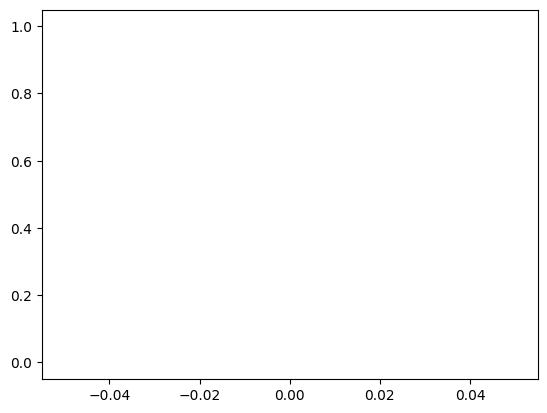

In [ ]:
for i, spectrum in enumerate(spectra.flatten()):
    plt.plot(spectrum)
    if i == 10:
        break

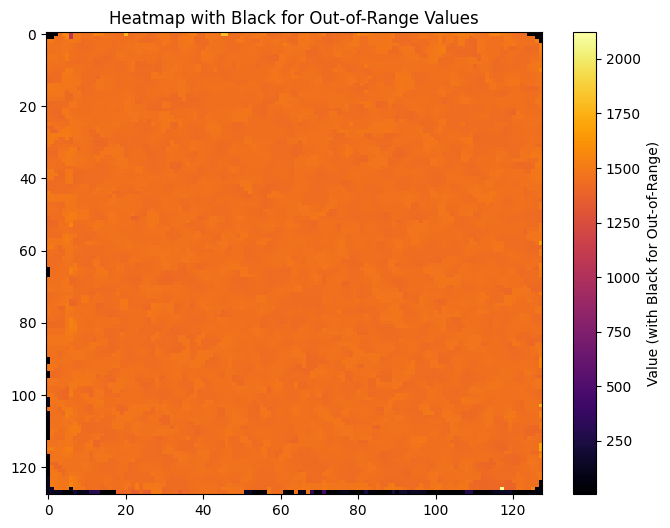

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

max_positions = np.argmax(spectra, axis=2)
# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(max_positions, cmap="inferno", aspect="auto")
plt.colorbar(label="Value (with Black for Out-of-Range)")
plt.title("Heatmap with Black for Out-of-Range Values")
plt.show()
